In [1]:
import pickle
from langchain_text_splitters import RecursiveCharacterTextSplitter

f:\Guvi\Old\Projects\project7\venv_new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DOCUMENT_PATH = "../data/documents.pkl"

In [3]:
with open(DOCUMENT_PATH, "rb") as file:
    documents = pickle.load(file)

print(f"Loaded {len(documents)} documents.")

Loaded 5 documents.


In [4]:
documents[0]

Document(metadata={'source': 'FAQ', 'category': 'Policy'}, page_content='\nQuestion:\nOrder Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.\n\nAnswer:\nOrder Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.\n')

In [5]:
print(documents[0].page_content)


Question:
Order Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.

Answer:
Order Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.



In [6]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    separators=[
        "\n\n",
        "\n",
        ". ",
        " ",
        ""
    ]
)

In [7]:
chunks = text_splitter.split_documents(documents)

print(f"Total Chunks Created: {len(chunks)}")

Total Chunks Created: 14


In [8]:
chunks[0]

Document(metadata={'source': 'FAQ', 'category': 'Policy'}, page_content='Question:\nOrder Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.')

In [9]:
print(chunks[0].page_content)

Question:
Order Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.


In [10]:
for i in range(3):
    print("=" * 80)
    print(f"Chunk {i+1}")
    print()
    print(chunks[i].page_content)
    print()

Chunk 1

Question:
Order Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.

Chunk 2

Answer:
Order Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.

Chunk 3

Question:
Cancellation and Restocking FeesOrders for small electronics (I

In [11]:
chunk_lengths = [len(chunk.page_content) for chunk in chunks]
print("Total Chunks :", len(chunk_lengths))
print("Average Size :", round(sum(chunk_lengths)/len(chunk_lengths),2))
print("Minimum Size :", min(chunk_lengths))
print("Maximum Size :", max(chunk_lengths))

Total Chunks : 14
Average Size : 394.79
Minimum Size : 171
Maximum Size : 500


In [12]:
import pandas as pd

stats = pd.DataFrame({

    "Chunk Number": range(1, len(chunk_lengths)+1),

    "Characters": chunk_lengths

})

stats.head()

,Chunk Number,Characters
0,1,449
1,2,447
2,3,352
3,4,350
4,5,355


In [13]:
stats.describe()

,Chunk Number,Characters
count,14.0000,14.000000
mean,7.5000,394.785714
std,4.1833,85.296026
min,1.0000,171.000000
25%,4.2500,353.500000
50%,7.5000,389.000000
75%,10.7500,448.500000
max,14.0000,500.000000


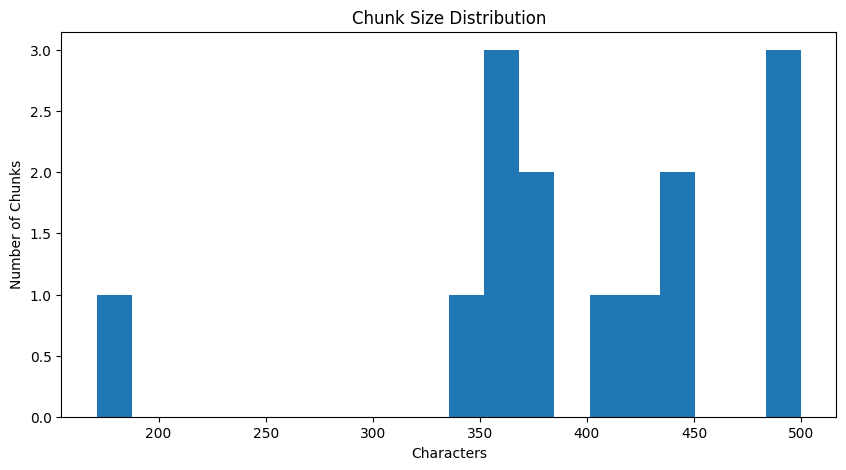

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.hist(chunk_lengths, bins=20)
plt.title("Chunk Size Distribution")
plt.xlabel("Characters")
plt.ylabel("Number of Chunks")
plt.show()

In [15]:
CHUNK_PATH = "../data/document_chunks.pkl"
with open(CHUNK_PATH, "wb") as file:
    pickle.dump(chunks, file)
print("Chunked documents saved successfully.")

Chunked documents saved successfully.


In [16]:
with open(CHUNK_PATH, "rb") as file:
    loaded_chunks = pickle.load(file)
print(f"Loaded {len(loaded_chunks)} chunks.")

Loaded 14 chunks.


In [17]:
loaded_chunks[0]

Document(metadata={'source': 'FAQ', 'category': 'Policy'}, page_content='Question:\nOrder Confirmation and Large Item DeliveryAll purchases receive a 10-digit Order ID. For large appliances (refrigerators, washing machines), you will receive a call from our logistics partner within 48 hours to schedule a delivery window (4-hour slots). Delivery includes basic installation and removal of old appliances, unless explicitly declined at checkout. Check your spam folder if the Order Confirmation is missing after 30 minutes.')